In [ ]:
librarian::shelf(tidyverse,visdat,geosphere, tidymodels, propensity, dagitty, ggdag, ggokabeito, patchwork)

In [ ]:
theme_wfp <- function(...) {
    theme_minimal(base_size = 12, base_family = "sans") +
        theme(
            plot.title = element_text(
                face = "bold", size = 14,
                margin = margin_auto(0, 0, 6, 0)
            ),
            plot.subtitle = element_text(
                colour = "grey40", size = 11,
                margin = margin_auto(0, 0, 10, 0)
            ),
            plot.caption = element_text(colour = "grey55", size = 9, hjust = 0),
            panel.grid.minor = element_blank(),
            panel.grid.major = element_line(colour = "grey90", linewidth = 0.4),
            strip.text = element_text(face = "bold", size = 10),
            legend.position = "bottom",
            legend.key.size = unit(4, "mm"),
            axis.title = element_text(size = 10)
        ) +
        theme(...)
}

covid_date <- as.Date("2020-03-01")

In [ ]:
data <- read_csv(
    here::here("data", "wfp_food_prices_ken.csv"),
    skip = 2,
    col_names = c(
        "date", "admin1", "admin2", "market",
        "latitude", "longitude", "category", "commodity",
        "unit", "price_flag", "price_type", "currency",
        "price", "usd_price"
    ),
    col_types = cols(
        date      = col_date(format = "%Y-%m-%d"),
        price     = col_double(),
        usd_price = col_double(),
        latitude  = col_double(),
        longitude = col_double(),
        .default  = col_character()
    ),
    na = c("", "NA", "N/A")
) |> 
select(-currency)

In [ ]:
head(data)

# A tibble: 6 × 13
  date       admin1  admin2   market latitude longitude category commodity unit 
  <date>     <chr>   <chr>    <chr>     <dbl>     <dbl> <chr>    <chr>     <chr>
1 2006-01-15 Coast   Mombasa  Momba…    -4.05      39.7 cereals… Maize     KG   
2 2006-01-15 Coast   Mombasa  Momba…    -4.05      39.7 pulses … Beans     KG   
3 2006-01-15 Coast   Mombasa  Momba…    -4.05      39.7 pulses … Beans (d… 90 KG
4 2006-01-15 Eastern Kitui    Kitui     -1.37      38.0 cereals… Maize (w… KG   
5 2006-01-15 Eastern Kitui    Kitui     -1.37      38.0 pulses … Beans (d… KG   
6 2006-01-15 Eastern Marsabit Marsa…     2.33      38.0 cereals… Maize (w… KG   
# ℹ 4 more variables: price_flag <chr>, price_type <chr>, price <dbl>,
#   usd_price <dbl>

In [ ]:
nairobi_coords <- data |>
  filter(market == "Nairobi") |>  
  summarise(lon = first(longitude), lat = first(latitude))


nairobi_coords

# A tibble: 1 × 2
    lon   lat
  <dbl> <dbl>
1  36.8 -1.28

In [ ]:
data <- data  |> 
mutate(period = if_else(date >= covid_date, "post_covid", "pre_covid"),
        year = lubridate::year(date),
        month = lubridate::month(date, label = TRUE),
        dist_from_nrb =  distHaversine(
      cbind(longitude, latitude),
      cbind(nairobi_coords$lon, nairobi_coords$lat)
    ) / 1000)


# EDA

In [ ]:
head(data)

# A tibble: 6 × 17
  date       admin1  admin2   market latitude longitude category commodity unit 
  <date>     <chr>   <chr>    <chr>     <dbl>     <dbl> <chr>    <chr>     <chr>
1 2006-01-15 Coast   Mombasa  Momba…    -4.05      39.7 cereals… Maize     KG   
2 2006-01-15 Coast   Mombasa  Momba…    -4.05      39.7 pulses … Beans     KG   
3 2006-01-15 Coast   Mombasa  Momba…    -4.05      39.7 pulses … Beans (d… 90 KG
4 2006-01-15 Eastern Kitui    Kitui     -1.37      38.0 cereals… Maize (w… KG   
5 2006-01-15 Eastern Kitui    Kitui     -1.37      38.0 pulses … Beans (d… KG   
6 2006-01-15 Eastern Marsabit Marsa…     2.33      38.0 cereals… Maize (w… KG   
# ℹ 8 more variables: price_flag <chr>, price_type <chr>, price <dbl>,
#   usd_price <dbl>, period <chr>, year <dbl>, month <ord>, dist_from_nrb <dbl>

In [ ]:
tail(data)

# A tibble: 6 × 17
  date       admin1    admin2 market latitude longitude category commodity unit 
  <date>     <chr>     <chr>  <chr>     <dbl>     <dbl> <chr>    <chr>     <chr>
1 2023-12-15 Rift Val… Turka… Mogad…     3.72      34.9 cereals… Maize     KG   
2 2023-12-15 Rift Val… Turka… Mogad…     3.72      34.9 cereals… Maize fl… KG   
3 2023-12-15 Rift Val… Turka… Mogad…     3.72      34.9 cereals… Potatoes… KG   
4 2023-12-15 Rift Val… Turka… Mogad…     3.72      34.9 meat, f… Meat (go… KG   
5 2023-12-15 Rift Val… Turka… Mogad…     3.72      34.9 miscell… Salt      200 G
6 2023-12-15 Rift Val… Turka… Mogad…     3.72      34.9 miscell… Sugar     KG   
# ℹ 8 more variables: price_flag <chr>, price_type <chr>, price <dbl>,
#   usd_price <dbl>, period <chr>, year <dbl>, month <ord>, dist_from_nrb <dbl>

In [ ]:
food <- data  |> 
filter(category != "non-food")

fuel <- data |> 
filter(category == "non-food")



In [ ]:
data |> 
  group_by(commodity) |> 
  filter(price_type == "Retail") |>  
  select(commodity) |> 
  count(sort = TRUE)

# A tibble: 28 × 2
# Groups:   commodity [28]
   commodity            n
   <chr>            <int>
 1 Maize (white)      669
 2 Beans (dry)        513
 3 Oil (vegetable)    372
 4 Maize              341
 5 Salt               272
 6 Sugar              272
 7 Rice               268
 8 Wheat flour        262
 9 Maize flour        261
10 Potatoes (Irish)   261
# ℹ 18 more rows
# ℹ Use `print(n = ...)` to see more rows

In [ ]:
key_commodities <- c(
  "Maize (white)",
  "Beans (dry)",
  "Oil (vegetable)",
  "Sugar"
)

In [ ]:
data |> 
  summarise(
    markets = n_distinct(market),
    obs = n(),
    .by = admin1
  ) |> 
  arrange(desc(obs)) |> 
  print()

# A tibble: 7 × 3
  admin1        markets   obs
  <chr>           <int> <int>
1 Rift Valley        20  4163
2 Nairobi             9  2290
3 North Eastern       9  1176
4 Eastern            10  1091
5 Coast              11  1072
6 Nyanza              2   838
7 Central             1   136


In [ ]:
names(data)

 [1] "date"          "admin1"        "admin2"        "market"       
 [5] "latitude"      "longitude"     "category"      "commodity"    
 [9] "unit"          "price_flag"    "price_type"    "price"        
[13] "usd_price"     "period"        "year"          "month"        
[17] "dist_from_nrb"

In [ ]:
# Do price type change after the brea point period on average?

data  |> 
    group_by(period) |> 
    filter(commodity %in% key_commodities) |>
    filter(price_type == "Retail")  |> 
    summarise(mean_price = mean(price, na.rm = TRUE)) |> 
    print()

# A tibble: 2 × 2
  period     mean_price
  <chr>           <dbl>
1 post_covid      155. 
2 pre_covid        71.9


In [ ]:
food <- food |> 
  mutate(
    price = case_when(
      commodity == "Maize (white)" & unit == "90 KG" ~ price / 90,
      commodity == "Beans (dry)" & unit == "90 KG" ~ price / 90,
      .default = price
    ),
    unit = case_when(
      commodity == "Maize (white)" & unit == "90 KG" ~ "KG",
      commodity == "Beans (dry)" & unit == "90 KG" ~ "KG",
      .default = unit
    )
  )

In [ ]:
price_series <- food |> 
    filter(commodity %in% key_commodities, price_type == "Retail") |> 
    summarise(median_price = median(price, na.rm = TRUE), .by = c(date, commodity))

price_series |> head()


# A tibble: 6 × 3
  date       commodity       median_price
  <date>     <chr>                  <dbl>
1 2006-01-15 Maize (white)           23.5
2 2006-01-15 Beans (dry)             39  
3 2006-01-15 Oil (vegetable)        115  
4 2006-02-15 Maize (white)           25.5
5 2006-02-15 Oil (vegetable)        120  
6 2006-03-15 Maize (white)           22  

In [ ]:
unique(price_series$commodity)

[1] "Maize (white)"   "Beans (dry)"     "Oil (vegetable)" "Sugar"          

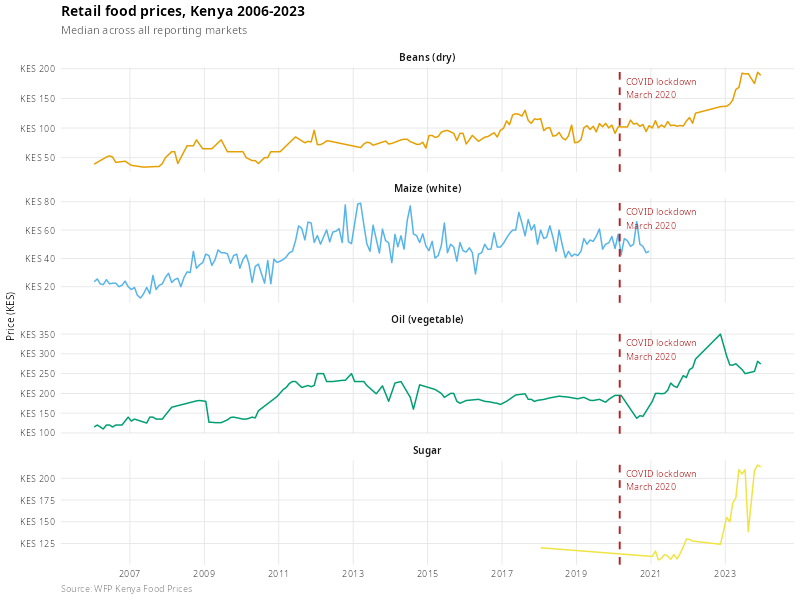

In [ ]:
p_series <- price_series |>
    ggplot(aes(x = date, y = median_price, colour = commodity)) +
    geom_line(linewidth = 0.7) +
    geom_vline(
        xintercept = covid_date,
        colour = "firebrick", linewidth = 0.9, linetype = "dashed"
    ) +
    annotate(
        "text",
        x = covid_date + 60, y = Inf,
        label = "COVID lockdown\nMarch 2020",
        vjust = 1.5, hjust = 0, size = 3.2, colour = "firebrick"
    ) +
    scale_colour_okabe_ito(name = NULL) +
    scale_y_continuous(labels = label_comma(prefix = "KES ")) +
    scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
    facet_wrap(~commodity, scales = "free_y", ncol = 1) +
    labs(
        title = "Retail food prices, Kenya 2006-2023",
        subtitle = "Median across all reporting markets",
        x = NULL,
        y = "Price (KES)",
        caption  = "Source: WFP Kenya Food Prices"
    ) +
    theme_wfp(legend.position = "none")

print(p_series)

In [ ]:
covid_date

[1] "2020-03-01"

In [ ]:
covid_date - months(12)

[1] "2019-03-01"

In [ ]:
# Food prices for the 12 months before and after covid

shock_window <-food |> 
filter(
    date >= covid_date - months(12) & date <= covid_date + months(12),
    price_type == "Retail"
) |> 
mutate(window = if_else(date < covid_date, "Pre (Mar 2019 - Feb 2020)", "Post (Mar 2020 - Feb 2021)"))

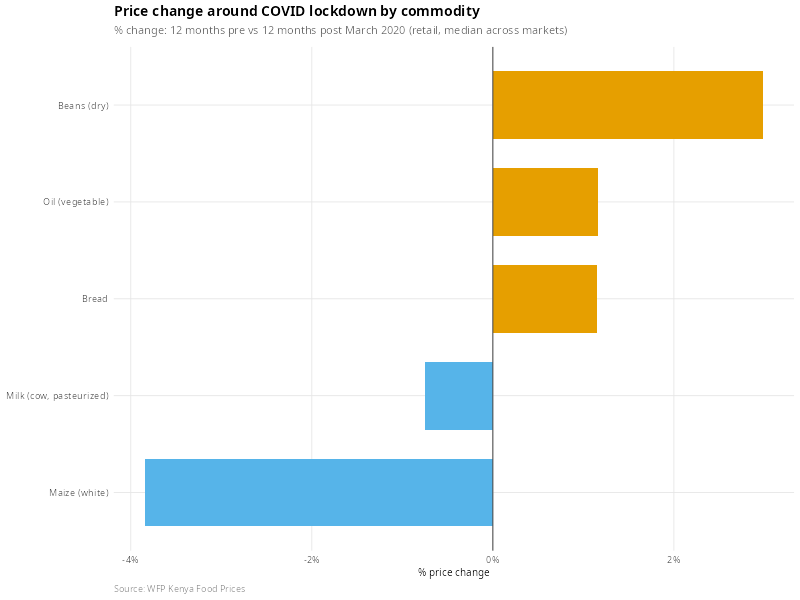

In [ ]:
pct_change <- shock_window |>
    summarise(
        median_price = median(price, na.rm = TRUE),
        .by = c(commodity, window)
    ) |>
    pivot_wider(names_from = window, values_from = median_price) |>
    janitor::clean_names() |>
    mutate(
        pct_change = (post_mar_2020_feb_2021 - pre_mar_2019_feb_2020) / pre_mar_2019_feb_2020 * 100
    ) |>
    filter(!is.na(pct_change)) |>
    arrange(desc(pct_change))

p_shock <- pct_change |>
    mutate(commodity = fct_reorder(commodity, pct_change)) |>
    ggplot(aes(x = pct_change, y = commodity, fill = pct_change > 0)) +
    geom_col(width = 0.7) +
    geom_vline(xintercept = 0, colour = "grey30", linewidth = 0.5) +
    scale_fill_manual(values = c("TRUE" = "#E69F00", "FALSE" = "#56B4E9"), guide = "none") +
    scale_x_continuous(labels = label_percent(scale = 1)) +
    labs(
        title    = "Price change around COVID lockdown by commodity",
        subtitle = "% change: 12 months pre vs 12 months post March 2020 (retail, median across markets)",
        x        = "% price change",
        y        = NULL,
        caption  = "Source: WFP Kenya Food Prices"
    ) +
    theme_wfp()

print(p_shock)

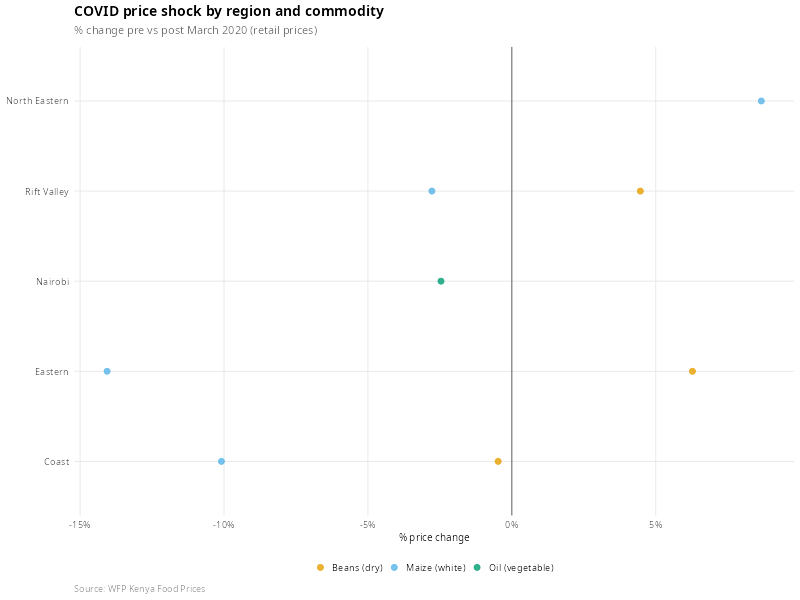

In [ ]:
regional_shock <- food |>
    filter(
        commodity %in% key_commodities,
        price_type == "Retail",
        date >= covid_date - months(12),
        date <= covid_date + months(12)
    ) |>
    mutate(window = if_else(date < covid_date, "pre", "post")) |>
    summarise(
        median_price = median(price, na.rm = TRUE),
        .by = c(admin1, commodity, window)
    ) |>
    pivot_wider(names_from = window, values_from = median_price) |>
    mutate(pct_change = (post - pre) / pre * 100) |>
    filter(!is.na(pct_change))

p_regional <- regional_shock |>
    mutate(admin1 = fct_reorder(admin1, pct_change, .fun = median)) |>
    ggplot(aes(x = pct_change, y = admin1, colour = commodity)) +
    geom_point(size = 2.5, alpha = 0.8) +
    geom_vline(xintercept = 0, colour = "grey30", linewidth = 0.4) +
    scale_colour_okabe_ito(name = NULL) +
    scale_x_continuous(labels = label_percent(scale = 1)) +
    labs(
        title    = "COVID price shock by region and commodity",
        subtitle = "% change pre vs post March 2020 (retail prices)",
        x        = "% price change",
        y        = NULL,
        caption  = "Source: WFP Kenya Food Prices"
    ) + theme_wfp()

print(p_regional)

In [ ]:
names(shock_window)

 [1] "date"          "admin1"        "admin2"        "market"       
 [5] "latitude"      "longitude"     "category"      "commodity"    
 [9] "unit"          "price_flag"    "price_type"    "price"        
[13] "usd_price"     "period"        "year"          "month"        
[17] "dist_from_nrb" "window"       

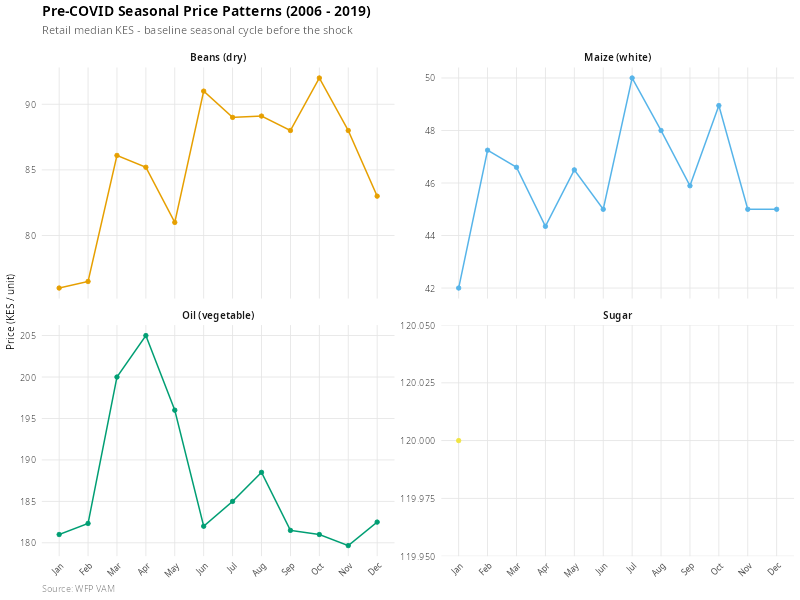

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?

In [ ]:
data |> 
  filter(year < 2020, price_type == "Retail", commodity %in% key_commodities) |> 
  summarise(median_kes = median(price, na.rm = TRUE), .by = c(month, commodity)) -> shock_data

# TODO: Remove the Sugar panel since it has only one data point
ggplot(shock_data, aes(month, median_kes, color = commodity, group = commodity)) +
  geom_line(linewidth = 0.7) +
  geom_point(size = 1.8) +
  scale_color_okabe_ito() +
  scale_y_continuous() +
  facet_wrap(~commodity, scales = "free_y") +
  labs(
        title = "Pre-COVID Seasonal Price Patterns (2006 - 2019)",
        subtitle = "Retail median KES - baseline seasonal cycle before the shock",
        x = NULL, y = "Price (KES / unit)",
        caption = "Source: WFP VAM"
    ) +
    theme_wfp(legend.position = "none") +
    theme_sub_axis_x(text = element_text(size = 8, angle = 45, hjust = 1))


In [ ]:
food |> 
  filter(commodity == "Maize") |> 
  distinct(price_type)

# A tibble: 2 × 1
  price_type
  <chr>     
1 Wholesale 
2 Retail    

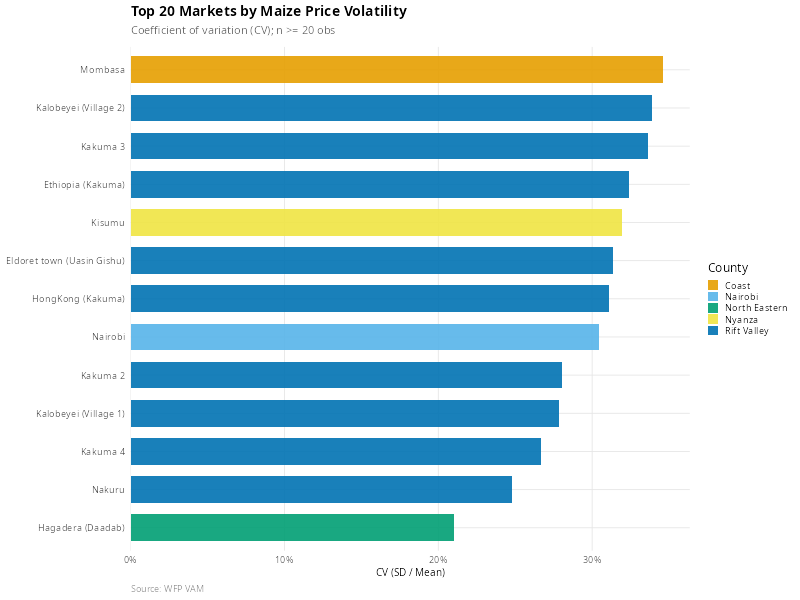

In [ ]:
cv_data <- food |> 
  filter(commodity == "Maize") |> 
  summarise(
    cv = sd(price, na.rm = TRUE) / mean(price, na.rm = TRUE),
    n = n(),
    .by = c(market, admin1)
  ) |> 
  filter(n >= 20) |> 
  slice_max(cv, n = 20)

ggplot(cv_data, aes(cv, reorder(market, cv), fill = admin1)) +
  geom_col(width = 0.7, alpha = 0.9) +
  scale_fill_okabe_ito() +
  scale_x_continuous(labels = label_percent(), expand = expansion(mult = c(0, 0.05))) +
  labs(
        title = "Top 20 Markets by Maize Price Volatility",
        subtitle = "Coefficient of variation (CV); n >= 20 obs",
        x = "CV (SD / Mean)", y = NULL,
        fill = "County",
        caption = "Source: WFP VAM"
    ) +
    theme_wfp(legend.position = "right")



In [ ]:
vline_covid <- geom_vline(
    xintercept = covid_date,
    colour     = "firebrick",
    linewidth  = 0.85,
    linetype   = "dashed"
)

label_covid <- annotate(
    "text",
    x      = covid_date + 75,
    y      = Inf,
    label  = "COVID-19\nMar 2020",
    vjust  = 1.6,
    hjust  = 0,
    size   = 3,
    colour = "firebrick"
)

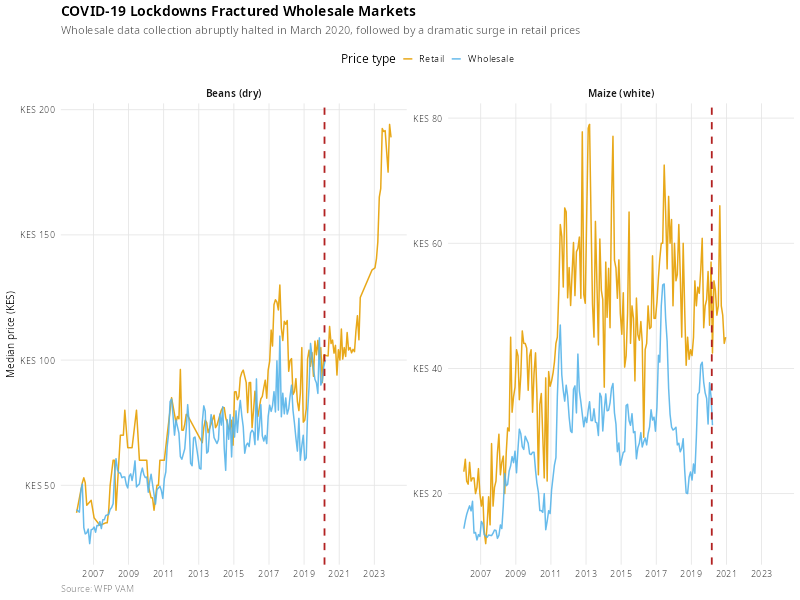

In [ ]:
comp_data <- food |>
    filter(
        commodity %in% c("Beans (dry)", "Maize (white)"),
        price_type %in% c("Retail", "Wholesale")
    ) |>
    summarise(
        median_price = median(price, na.rm = TRUE),
        .by = c(date, commodity, price_type)
    )

ggplot(comp_data, aes(x = date, y = median_price, colour = price_type)) +
    geom_line(linewidth = 0.7, alpha = 0.9) +
    vline_covid +
    scale_colour_okabe_ito(name = "Price type") +
    scale_y_continuous(labels = label_comma(prefix = "KES ")) +
    scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
    facet_wrap(~commodity, scales = "free_y") +
    labs(
        title = "COVID-19 Lockdowns Fractured Wholesale Markets",
        subtitle = "Wholesale data collection abruptly halted in March 2020, followed by a dramatic surge in retail prices",
        x = NULL, y = "Median price (KES)",
        caption = "Source: WFP VAM"
    ) +
    theme_wfp(legend.position = "top")

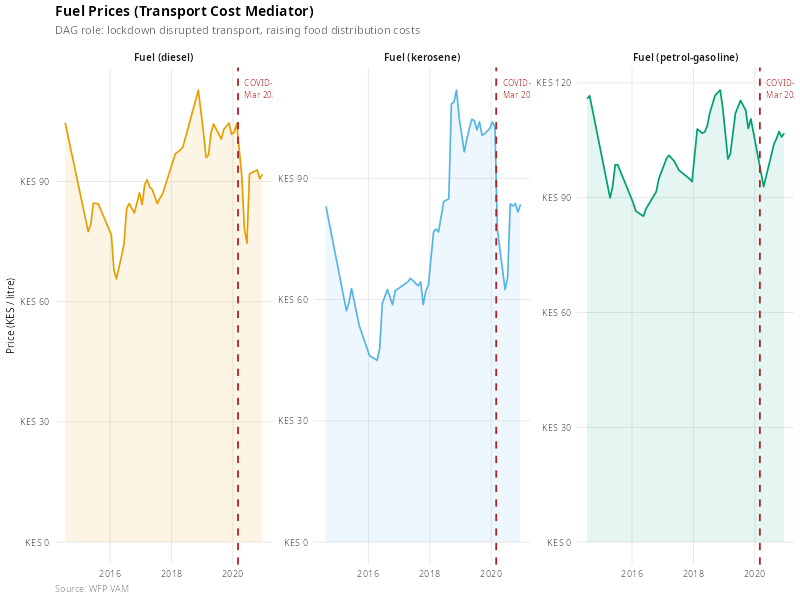

In [ ]:
fuel_data <- fuel |> 
  summarise(median_price = median(price, na.rm = TRUE), .by = c(date, commodity))

ggplot(fuel_data, aes(x = date, y = median_price, color = commodity)) +
  geom_area(aes(fill = commodity), alpha = 0.1, position = "identity", color = NA) +
  geom_line(linewidth = 0.8) +
  vline_covid  +
  label_covid +
  scale_color_okabe_ito() +
  scale_fill_okabe_ito() +
  guides(color = "none", fill = "none") +
  scale_y_continuous(labels = label_comma(prefix = "KES ")) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  facet_wrap(~commodity, scales = "free_y") +
  labs(
      title = "Fuel Prices (Transport Cost Mediator)",
      subtitle = "lockdown disrupted transport, raising food distribution costs",
      x = NULL, y = "Price (KES / litre)",
      caption = "Source: WFP VAM"
  ) +
  theme_wfp()

# DAG 

In [ ]:
head(data) |> kableExtra::kable()



|date       |admin1  |admin2   |market   |  latitude| longitude|category           |commodity     |unit  |price_flag |price_type |   price| usd_price|period    | year|month | dist_from_nrb|
|:----------|:-------|:--------|:--------|---------:|---------:|:------------------|:-------------|:-----|:----------|:----------|-------:|---------:|:---------|----:|:-----|-------------:|
|2006-01-15 |Coast   |Mombasa  |Mombasa  | -4.050000|  39.66667|cereals and tubers |Maize         |KG    |actual     |Wholesale  |   16.13|    0.2235|pre_covid | 2006|Jan   |      441.8946|
|2006-01-15 |Coast   |Mombasa  |Mombasa  | -4.050000|  39.66667|pulses and nuts    |Beans         |KG    |actual     |Wholesale  |   33.63|    0.4659|pre_covid | 2006|Jan   |      441.8946|
|2006-01-15 |Coast   |Mombasa  |Mombasa  | -4.050000|  39.66667|pulses and nuts    |Beans (dry)   |90 KG |actual     |Wholesale  | 3246.00|   44.9705|pre_covid | 2006|Jan   |      441.8946|
|2006-01-15 |Eastern |Kitui    |Kitui    | -1.36

Warning messages:
1: No shared levels found between `names(values)` of the manual scale and the data's
colour values. 
2: No shared levels found between `names(values)` of the manual scale and the data's fill
values. 


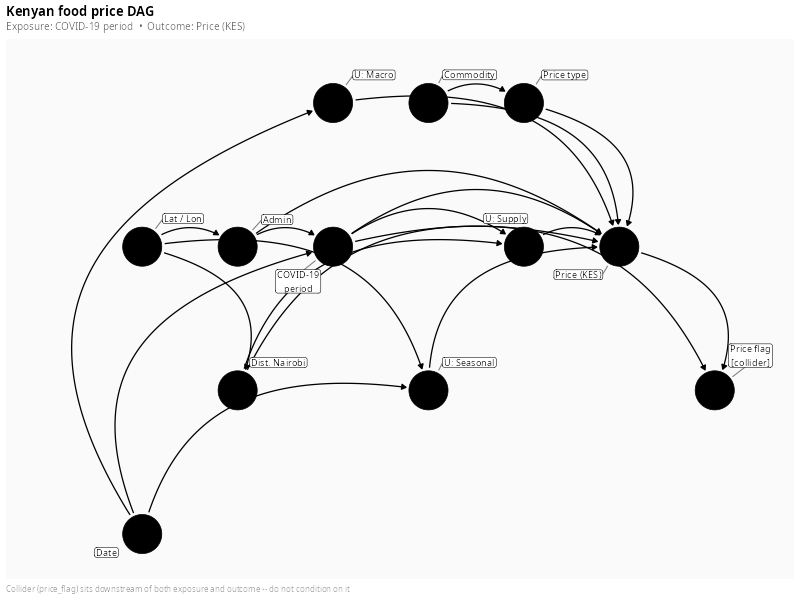

In [ ]:
coords <- list(
  x = c(
    date         = 1,
    latlon       = 1,
    admin        = 2,
    dist_nrb     = 2,
    covid_period = 3,
    u_macro      = 3,
    u_seasonal   = 4,
    commodity    = 4,
    u_supply     = 5,
    price_type   = 5,
    price_kes    = 6,
    price_flag   = 7
  ),
  y = c(
    date         = -2,
    latlon       =  2,
    admin        =  2,
    dist_nrb     =  0,
    covid_period =  2,
    u_macro      =  4,
    u_seasonal   =  0,
    commodity    =  4,
    u_supply     =  2,
    price_type   =  4,
    price_kes    =  2,
    price_flag   =  0
  )
)

# ---- DAG ---------------------------------------------------------------------

food_price_dag <- dagify(

  # Core outcome: price is a function of location, commodity, market structure,
  # temporal shocks, and the COVID-19 period (our exposure)
  price_kes ~ admin + dist_nrb + commodity + price_type +
    covid_period + u_macro + u_seasonal + u_supply,

  # price_flag is a COLLIDER: it is caused by both the exposure and the outcome.
  # Conditioning on it (e.g. filtering on flagged obs) opens a backdoor path
  # and induces spurious association -- so we must NOT adjust for it.
  price_flag ~ covid_period + price_kes,

  # u_supply is a mediator of the COVID effect that also depends on remoteness.
  # Including it as a confounder would block part of the causal path we care
  # about, so it stays as an intermediate node.
  u_supply ~ covid_period + dist_nrb,

  # Date drives both macro trend and seasonality. Splitting date into these two
  # latent components avoids a positivity violation: every observation has a
  # date, so conditioning on date directly would leave no variation to estimate
  # the COVID effect over.
  u_macro    ~ date,
  u_seasonal ~ date,

  # COVID period is itself partly determined by date (pandemic timeline) and by
  # administrative region (policy implementation varied by county/region).
  covid_period ~ date + admin,

  # Spatial structure: lat/lon is the root of all location-based confounders.
  # Admin boundaries and distance from Nairobi are derived from coordinates,
  # and seasonality varies spatially (e.g. bimodal vs unimodal rainfall zones).
  dist_nrb   ~ latlon,
  admin      ~ latlon,
  u_seasonal ~ latlon,

  # Commodity type determines which price concept is relevant (retail vs
  # wholesale vs farm gate), so price_type is downstream of commodity.
  price_type ~ commodity,

  exposure = "covid_period",
  outcome  = "price_kes",

  labels = c(
    date         = "Date",
    latlon       = "Lat / Lon",
    admin        = "Admin",
    dist_nrb     = "Dist. Nairobi",
    commodity    = "Commodity",
    price_type   = "Price type",
    covid_period = "COVID-19\nperiod",
    u_macro      = "U: Macro",
    u_seasonal   = "U: Seasonal",
    u_supply     = "U: Supply",
    price_kes    = "Price (KES)",
    price_flag   = "Price flag\n[collider]"
  ),

  coords = coords
)


food_price_dag |>
  ggdag(
    use_labels = "label",
    text       = FALSE,
    node_size  = 18,
    label_size = 3,
    edge_type  = "arc"           # slight curve reduces arrow pile-up
  ) +
  scale_color_manual(
    values = c(
      exposure = "#E07A5F",      # terracotta -- COVID node
      outcome  = "#3D405B",      # slate      -- Price (KES) node
      latent   = "#81B29A"       # sage       -- unobserved U nodes
    ),
    na.value = "#B4B2A9"         # warm grey for all other nodes
  ) +
  scale_fill_manual(
    values = c(
      exposure = "#E07A5F",
      outcome  = "#3D405B",
      latent   = "#81B29A"
    ),
    na.value = "#B4B2A9"
  ) +
  labs(
    title    = "Kenyan food price DAG",
    subtitle = "Exposure: COVID-19 period  \u2022  Outcome: Price (KES)",
    caption  = "Collider (price_flag) sits downstream of both exposure and outcome -- do not condition on it"
  ) +
  theme_dag(base_family = "sans") +
  theme(
    plot.title       = element_text(size = 13, face = "bold",  margin = margin(b = 3)),
    plot.subtitle    = element_text(size = 10, colour = "grey40", margin = margin(b = 6)),
    plot.caption     = element_text(size = 8,  colour = "grey55", hjust = 0),
    legend.position  = "none",
    plot.background  = element_rect(fill = "white", colour = NA),
    panel.background = element_rect(fill = "grey98", colour = NA)
  )

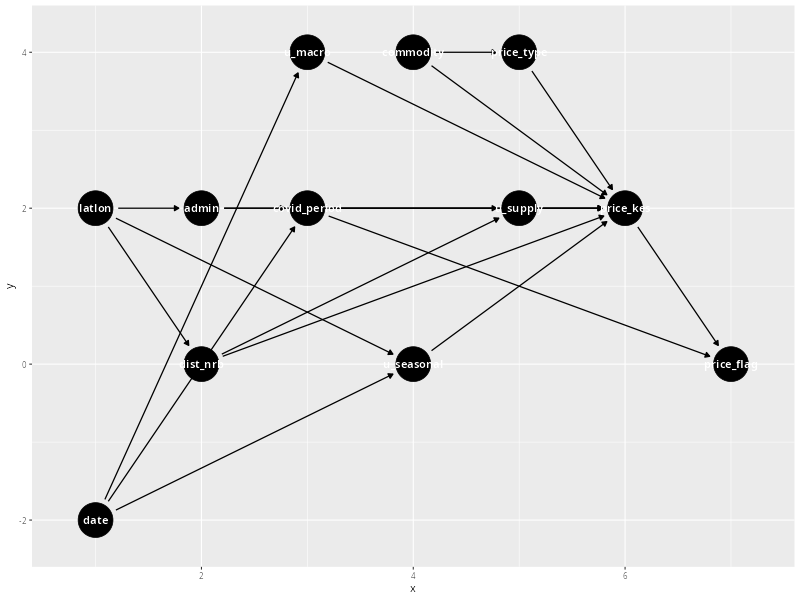

In [ ]:
food_price_dag |> 
  ggdag()

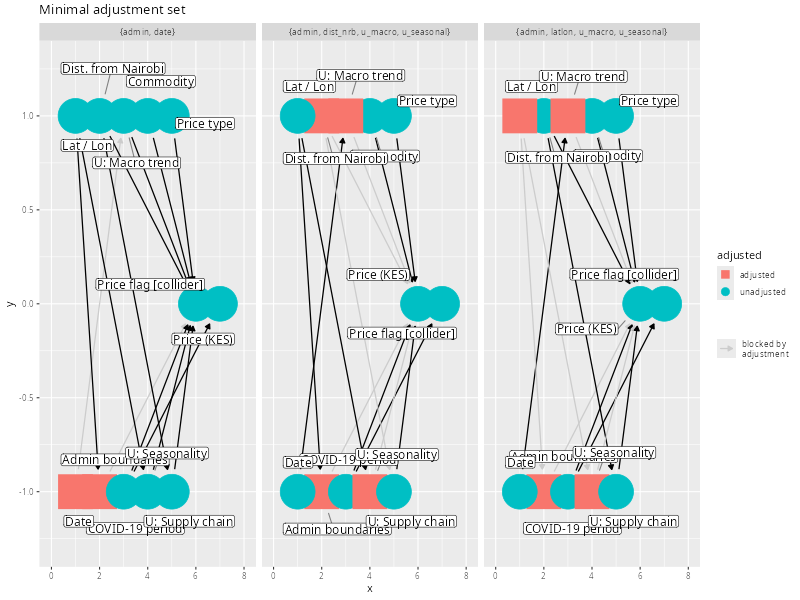

In [ ]:

pal <- c(
  adjusted          = "#E07A5F",   # terracotta
  unadjusted        = "#81B29A",   # sage
  `blocked by\nadjustment` = "#D4C5B0"  # warm sand
)


ggdag_adjustment_set(
  food_price_dag,
  text       = FALSE,
  use_labels = "label",
  node_size  = 14,
  shadow     = TRUE
) +
  scale_color_manual(
    values = pal,
    name   = NULL,
    guide  = guide_legend(override.aes = list(size = 4))
  ) +
  scale_fill_manual(values = pal, name = NULL) +
  labs(
    title    = "Minimal adjustment set",
    subtitle = "Exposure: COVID-19 period  |  Outcome: Price (KES)",
    caption  = "Nodes coloured by adjustment status within each sufficient set"
  ) +
  theme_dag(base_family = "sans") +
  theme(
    plot.title         = element_text(size = 13, face = "bold",  margin = margin(b = 4)),
    plot.subtitle      = element_text(size = 10, colour = "grey40", margin = margin(b = 8)),
    plot.caption       = element_text(size = 8,  colour = "grey55", hjust = 0),
    legend.position    = "bottom",
    legend.text        = element_text(size = 9),
    strip.text         = element_text(size = 7.5, face = "bold"),
    strip.background   = element_rect(fill = "grey94", colour = NA),
    panel.spacing      = unit(1.2, "lines"),
    plot.background    = element_rect(fill = "white", colour = NA),
    panel.background   = element_rect(fill = "grey98", colour = NA)
  )

ggsave(
  "food_price_dag_adjset.png",
  width = 14, height = 6, dpi = 180, bg = "white"
)

In [ ]:
unique(data$price_flag)

[1] "actual"    "aggregate"

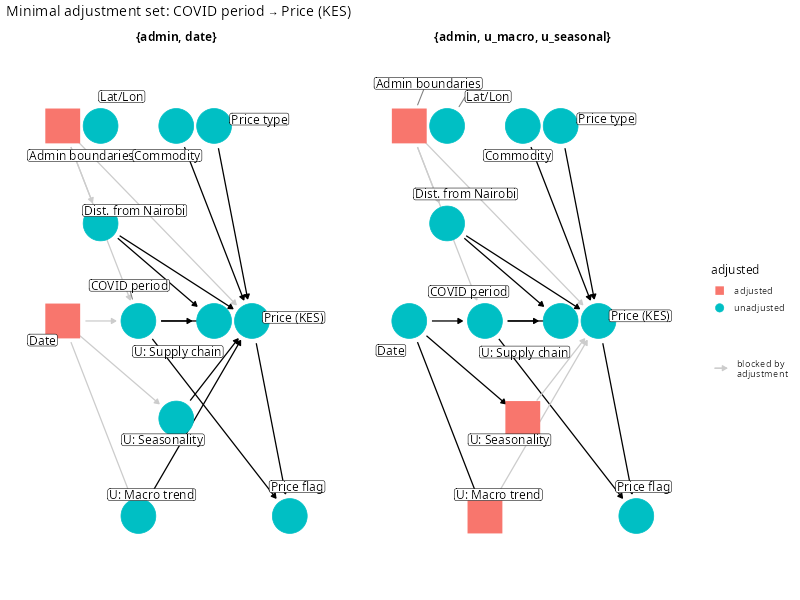

In [ ]:
# adjustment set plot -- will flag price_flag as collider automatically
ggdag_adjustment_set(
  food_price_dag,
  use_labels = "label",
  text       = FALSE,
  shadow     = TRUE
) +
  theme_dag() +
  labs(title = "Minimal adjustment set: COVID period → Price (KES)")

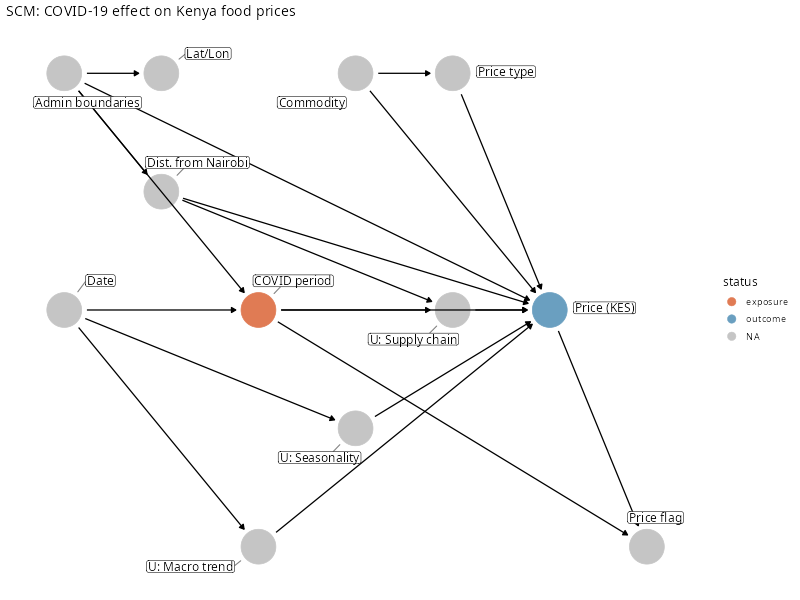

In [ ]:
# highlight exposure/outcome status
ggdag_status(food_price_dag, use_labels = "label", text = FALSE) +
  scale_color_manual(
    values = c(
      exposure = "#E07B54",
      outcome  = "#6A9FC0",
      latent   = "#A8A8A8"
    ),
    na.value = "#C5C5C5"
  ) +
  theme_dag() +
  labs(title = "SCM: COVID-19 effect on Kenya food prices")

In [ ]:
# adjustment set
dagitty::adjustmentSets(food_price_dag, type = "minimal")

# all paths from treatment to outcome
dagitty::paths(food_price_dag, from = "covid_period", to = "price_kes")

# testable independence claims to validate against data
dagitty::impliedConditionalIndependencies(food_price_dag)

admn _||_ cmmd
admn _||_ date
admn _||_ prc_f | cvd_, prc_k
admn _||_ prc_
admn _||_ u_mc
admn _||_ u_ss
admn _||_ u_sp | cvd_, dst_
cmmd _||_ cvd_
cmmd _||_ date
cmmd _||_ dst_
cmmd _||_ ltln
cmmd _||_ prc_f | cvd_, prc_k
cmmd _||_ u_mc
cmmd _||_ u_ss
cmmd _||_ u_sp
cvd_ _||_ dst_ | admn
cvd_ _||_ ltln | admn
cvd_ _||_ prc_
cvd_ _||_ u_mc | date
cvd_ _||_ u_ss | date
date _||_ dst_
date _||_ ltln
date _||_ prc_f | cvd_, prc_k
date _||_ prc_ | admn, cvd_, u_mc, u_ss
date _||_ prc_ | admn, cvd_, u_mc, u_ss
date _||_ prc_
date _||_ u_sp | cvd_, dst_
date _||_ u_sp | admn, cvd_
dst_ _||_ ltln | admn
dst_ _||_ prc_f | cvd_, prc_k
dst_ _||_ prc_
dst_ _||_ u_mc
dst_ _||_ u_ss
ltln _||_ prc_f | cvd_, prc_k
ltln _||_ prc_ | admn
ltln _||_ prc_ | admn
ltln _||_ prc_
ltln _||_ u_mc
ltln _||_ u_ss
ltln _||_ u_sp | cvd_, dst_
ltln _||_ u_sp | admn
prc_f _||_ prc_t | cvd_, prc_k
prc_f _||_ u_mc | cvd_, prc_k
prc_f _||_ u_ss | cvd_, prc_k
prc_f _||_ u_sp | cvd_, prc_k
prc_ _||_ u_mc
prc_ _||_ u_ss
p